In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (mean_absolute_error,mean_squared_error,root_mean_squared_error)



In [ ]:
# Load data
train = pd.read_pickle("../models/train_data.pkl")
test = pd.read_pickle("../models/test_data.pkl")

test_values = test["Passengers"].values

# Load trained models
arima_model = joblib.load("../models/arima_model.pkl")
sarima_model = joblib.load("../models/sarima_model.pkl")

In [4]:
# Forecast
arima_forecast = arima_model.forecast(steps=12)

sarima_log = sarima_model.forecast(steps=12)
sarima_forecast = np.exp(sarima_log)


In [5]:
# ARIMA Evaluation
arima_mae = mean_absolute_error(test_values, arima_forecast)
arima_mse = mean_squared_error(test_values, arima_forecast)
arima_rmse = root_mean_squared_error(test_values, arima_forecast)

# SARIMA Evaluation
sarima_mae = mean_absolute_error(test_values, sarima_forecast)
sarima_mse = mean_squared_error(test_values, sarima_forecast)
sarima_rmse = root_mean_squared_error(test_values, sarima_forecast)


In [6]:

# Comparison Table
results = pd.DataFrame({
    "Model":["ARIMA","SARIMA"],
    "MAE":[arima_mae,sarima_mae],
    "MSE":[arima_mse,sarima_mse],
    "RMSE":[arima_rmse,sarima_rmse]
})

print(results)


    Model        MAE          MSE       RMSE
0   ARIMA  67.389003  7535.998692  86.810130
1  SARIMA  13.631965   354.060088  18.816484


In [7]:
# Save evaluation
results.to_csv("../data set/model_evaluation.csv",index=False)

# Best Model
best_model = results.loc[results["RMSE"].idxmin(),"Model"]
print(f"\nBest Model : {best_model}")



Best Model : SARIMA


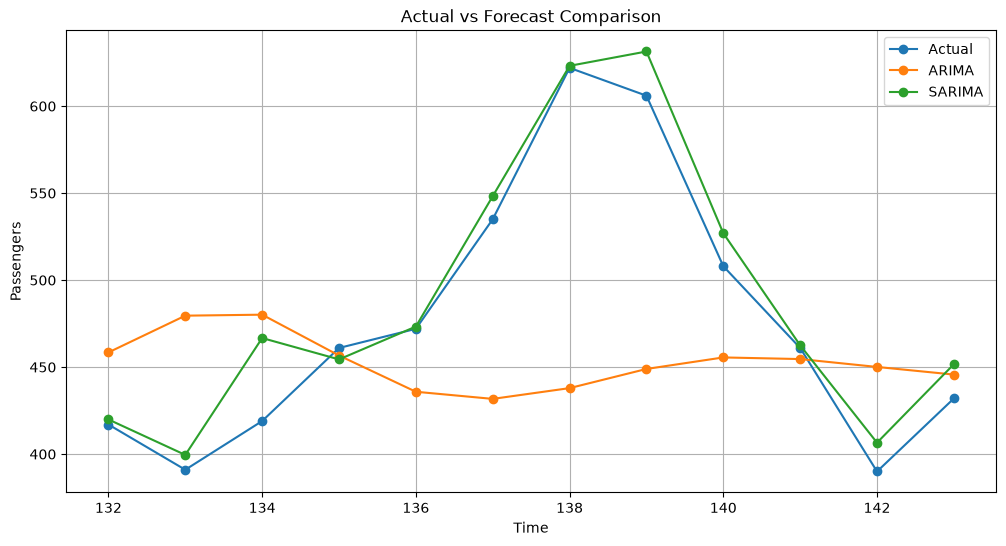

In [8]:
# Plot comparison
plt.figure(figsize=(12,6))
plt.plot(test.index,test_values,marker="o",label="Actual")
plt.plot(test.index,arima_forecast,marker="o",label="ARIMA")
plt.plot(test.index,sarima_forecast,marker="o",label="SARIMA")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.title("Actual vs Forecast Comparison")
plt.legend()
plt.grid(True)
plt.show()


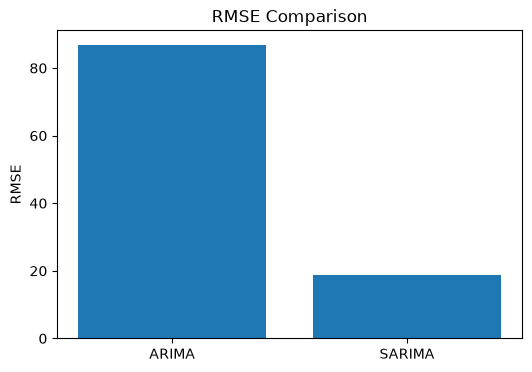

In [ ]:
# RMSE Comparison
plt.figure(figsize=(6,4))
plt.bar(results["Model"],results["RMSE"])
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()